# 正太分布

正态分布是最重要的一种概率分布。正态分布概念是由德国的数学家和天文学家Moivre（棣莫弗）于1733年受次提出的，但由于德国数学家Gauss（高斯）率先将其应用于天文学家研究，故正态分布又叫高斯分布。正态分布起源于误差分析，早期的天文学家通过长期对一些天体的观测收集到了大量数据，并利用这些数据天体运动的物理模型，其中第谷与开 普勒在建模中提出了一条原则—“模型选择的最终标准是其与观测数据的符合程度”，这个“符合程度”实质上蕴涵了误差概率理论的问题，伽例略是第一个在其著作中提出随机误差这一概念的人。因其曲线呈钟形，
因此人们又经常称之为钟形曲线。我们通常所说的标准正态分布是μ = 0,σ = 1的正态分布。


### 正态分布的定义

正态分布（Normal distribution）又名高斯分布（Gaussian distribution），是一个在数学、物理及工程等领域都非常重要的概率分布，在统计学的许多方面有着重大的影响力。正态分布之所以被称为正态，是因为它的形态看起来合乎理想。在现实生活中，遇到测量之类的大量连续数据时，你"正常情况下"会期望看到这种形态。
<img src="images/20220517205642.png">
<img src="images/20220517210209.png">

### 正态分布函数密度曲线可以表示为

<img src="images/20220517205925.png" style="height:100px">

#### 标准正态分布
<img src="images/20220517210109.png" style="height:130px"/>

下面列出的变量的分布都比较接近正态分布：

    人群的身高
    成年人的血压
    传播中的粒子的位置
    测量误差
    回归中的残差
    人群的鞋码
    一天中雇员回家的总耗时
    教育指标

正态分布只依赖于数据集的两个特征：样本的均值和方差。

    均值——样本所有取值的平均
    方差——该指标衡量了样本总体偏离均值的程度

正态分布的这种统计特性使得问题变得异常简单，任何具有正态分布的变量，都可以进行高精度分预测。

值得注意的是，大自然中发现的变量，大多近似服从正态分布。

正态分布很容易解释，这是因为：

    正态分布的均值，模和中位数是相等的。
    我们只需要用均值和标准差就能解释整个分布。

正态分布是我们熟悉的正常行为。

#### 为何如此多的变量都大致服从正态分布？
这个现象可以由如下定理解释：当在大量随机变量上重复很多次实验时，它们的分布总和将非常接近正态分布。

由于人的身高是一个随机变量，并且基于其他随机变量，例如一个人消耗的营养量，他们所处的环境，他们的遗传等等，这些变量的分布总和最终是非常接近正态的。

这就是中心极限定理。

#### 特点
<img src="images/20220517210908.png" style="height:350px">
<img src="images/20220517210953.png" style="height:220px">

## 正态性检验

利用观测数据判断总体是否服从正态分布的检验称为正态性检验，它是统计判决中重要的一种特殊的拟合优度假设检验。

直方图初判 / Q-Q图判断 / K-S检验

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 创建随机数据
s = pd.DataFrame(np.random.randn(1000)+10,columns = ['value'])
s.head()

,value
0,8.901069
1,11.021969
2,8.936208
3,10.101009
4,11.399998


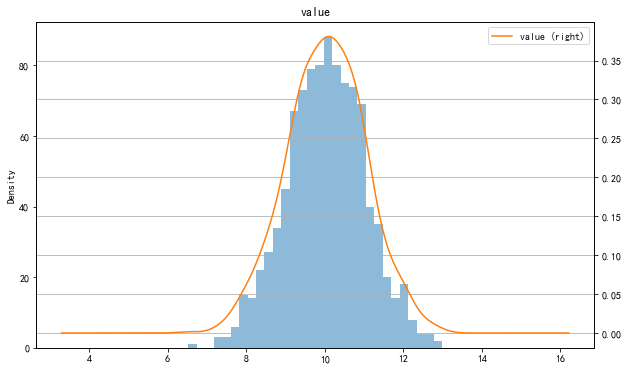

In [3]:
# 绘制直方图
# 呈现较明显的正太性
fig = plt.figure(figsize = (10,6))
ax1 = fig.add_subplot(1,1,1)  # 创建子图1
s.hist(bins=30,alpha = 0.5, ax=ax1)
# 开启第二个y坐标   密度图
s.plot(kind = 'kde', secondary_y=True, ax=ax1)
plt.grid()

密度图也被称作KDE（Kernel Density Estimate,核密度估计）图。调用plot时加上kind='kde'即可生成一张密度图（标准混合正态分布KDE）

这两种图表常常会被画在一起。直方图以规格化形式给出（以便给出面元化密度），然后再在其上绘制核密度估计

####  QQ图判断
- QQ图通过把测试样本数据的分位数与已知分布相比较，从而来检验数据的分布情况

- QQ图是一种散点图，对应于正态分布的QQ图，就是由标准正态分布的分位数为横坐标，样本值为纵坐标的散点图

        分位数（Quantile），亦称分位点，是指将一个随机变量的概率分布范围分为几个等份的数值点，常用的有中位数（即二分位数）、四分位数、百分位数等。
        百分位数，统计学术语，如果将一组数据从小到大排序，并计算相应的累计百分位，则某一百分位所对应数据的值就称为这一百分位的百分位数
        
- 参考直线：四分之一分位点和四分之三分位点这两点确定，看散点是否落在这条线的附近

#### 绘制思路

        ① 在做好数据清洗后，对数据进行排序（次序统计量：x(1)<x(2)<....<x(n)）
        ② 排序后，计算出每个数据对应的百分位p{i}，即第i个数据x(i)为p(i)分位数，其中p(i)=(i-0.5)/n （pi有多重算法，这里以最常用方法为主）
        ③ 绘制直方图 + qq图，直方图作为参考

In [4]:
s = pd.DataFrame(np.random.randn(1000)+10, columns=['value'])
s.head(3)

,value
0,10.217628
1,8.905869
2,11.154204


In [5]:
s.sort_values(by='value', inplace=True)
s_r = s.reset_index(drop=False)
s_r.head()

,index,value
0,26,7.129327
1,554,7.199873
2,197,7.444307
3,996,7.574249
4,526,7.615959


In [6]:
s_r['p'] = (s_r.index+1-0.5)/len(s_r) #计算百分位数
s_r

,index,value,p
0,26,7.129327,0.0005
1,554,7.199873,0.0015
2,197,7.444307,0.0025
3,996,7.574249,0.0035
4,526,7.615959,0.0045
...,...,...,...
995,324,12.654717,0.9955
996,35,12.703350,0.9965
997,217,12.792094,0.9975
998,395,13.218773,0.9985


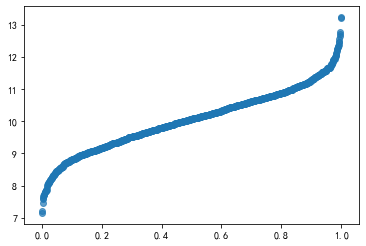

In [8]:
plt.scatter(s_r['p'], s_r['value'], cmap='Reds', alpha=0.7) # 绘制Q-Q图

In [ ]:
mean = s['value'].mean()
std = s['value'].std()
print('均值为：%.2f,标准差为：%.2f' % (mean, std))

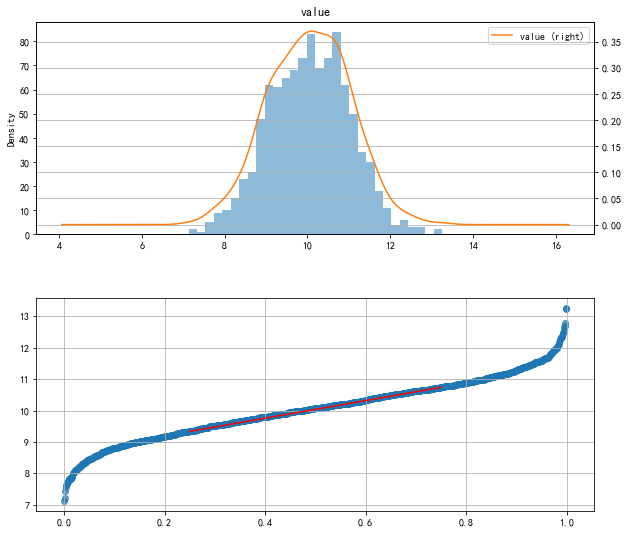

In [9]:
# 四分之一分位点和四分之三分位点
st = s['value'].describe()
x1, y1 = 0.25, st['25%']
x2, y2 = 0.75, st['75%']
# 绘制直方图和密度图
fig = plt.figure(figsize=(10, 9))
ax1 = fig.add_subplot(2, 1, 1)
s.hist(bins=30, alpha=0.5, ax=ax1)
s.plot(kind='kde', secondary_y=True, ax=ax1)
plt.grid()

#plt.plot(s_r['value'],s_r['q']) 
# 绘制Q-Q图
ax2 = fig.add_subplot(2, 1, 2)
ax2.scatter(s_r['p'], s_r['value'], cmap='Reds', alpha=0.7) # 绘制Q-Q图

ax2.plot([x1, x2], [y1, y2], '-r') #添加一条直线
plt.grid()


 将数据修改为使用np.random.rand 均匀分布,使用柱状图我们可以看出 不满足正太分布,Q-Q图也不是一个正太分布的图

## KS-检验 -- 检验数据是否符合某种分布

是比较一个频率分布f(x)与理论分布g(x)或者两个观测值分布的检验方法

以样本数据的`累计频数分布`和`特定的理论分布比较(比如正太分布)`进行比较,如果两者差距小,则推论样本分布取自某个特定分布

#### 建设性检验
    
        H0:样本的总体分布服从某个特定分布
        H1:样本的总部分布,不服从某个特定分布

Fn(x)-->样本的累计分布函数

F0(x)-->理论分布的分布函数(样本进行标准化取值后对应的正太分布值)
    
    标准化数据:经过处理的数据符合标准正态分布，即均值为0，标准差为1，其转化函数为
        （x−μ）/σ :(x-均值)/标准差

D-->Fn(x)与F0(x)差值的绝对值的最大值

D = max|Fn(x)-F0(x)|

当实际观测值D>D(n,α)则拒绝H0，否则则接受H0假设

<span style="color:red">p>0.5接受H0, p<0.5拒绝H0,接收H1</a>


#### 累积频率

`累积频率`（Cumulative Frequencies），按某种标志对数据进行分组后，分布在各组内的数据个数称为频数或次数，各组频数与全部频数之和的比值称为频率或比重。

为了统计分析的需要，有时需要观察某一数值以下或某一数值以上的频率之和，叫做`累积频率`，或叫做对频率的累计。从变量值小的一方向变量值大的一方累加，称为向上累积，反之为向下累积。频率的最终累积值为100%。

#### P值 


P值是用来判定假设检验结果的一个参数，也可以根据不同的分布使用分布的拒绝域进行比较。由R·A·Fisher首先提出。
P值（P value）就是当原假设为真时，比所得到的样本观察结果更极端的结果出现的概率。如果P值很小，说明原假设情况的发生的概率很小，而如果出现了，根据小概率原理，我们就有理由拒绝原假设，P值越小，我们拒绝原假设的理由越充分。总之，P值越小，表明结果越显著。但是检验的结果究竟是“显著的”、“中度显著的”还是“高度显著的”需要我们自己根据P值的大小和实际问题来解决。


从研究总体中抽取一个随机样本计算检验统计量的值计算概率P值或者说观测的显著水平，即在假设为真时的前提下，检验统计量大于或等于实际观测值的概率。

        如果P<0.01，说明是较强的判定结果，拒绝假定的参数取值。
        如果0.01<P值<0.05，说明较弱的判定结果，拒绝假定的参数取值。
        如果P值>0.05，说明结果更倾向于接受假定的参数取值。

In [10]:
# 样本数据，35位健康男性在未进食之前的血糖浓度
data = [87,77,92,68,80,78,84,77,81,80,80,77,92,86,
       76,80,81,75,77,72,81,72,84,86,80,68,77,87,
       76,77,78,92,75,80,78]

In [11]:
# 查看数据基本统计量
df = pd.DataFrame(data, columns =['value'])
u = df['value'].mean() # 均值
std = df['value'].std() # 标准差
print("样本均值为：%.2f，样本标准差为：%.2f" % (u,std))

样本均值为：79.74，样本标准差为：5.94


In [15]:
df['value'].value_counts()

80    6
77    6
92    3
81    3
78    3
87    2
86    2
84    2
76    2
75    2
72    2
68    2
Name: value, dtype: int64

In [12]:
# 创建频率数据
s = df['value'].value_counts().sort_index()
df_s = pd.DataFrame({'血糖浓度':s.index,'次数':s.values})
df_s

,血糖浓度,次数
0,68,2
1,72,2
2,75,2
3,76,2
4,77,6
5,78,3
6,80,6
7,81,3
8,84,2
9,86,2


In [13]:
# D值序列计算结果表格
df_s['累计次数'] = df_s['次数'].cumsum()
#
df_s['累计频率'] = df_s['累计次数'] / len(data) # 35位
# 数据转化为标准分布,就可以查出他的理论分布.
df_s['标准化取值'] = (df_s['血糖浓度'] - u) / std
# 通过查阅正太分布表
df_s['理论分布'] =[0.0244,0.0968,0.2148,0.2643,0.3228,0.3859,0.5160,0.5832,0.7611,0.8531,0.8888,0.9803]  
df_s['D'] = np.abs(df_s['累计频率'] - df_s['理论分布'])
dmax = df_s['D'].max()
print("实际观测D值为：%.4f" % dmax)

实际观测D值为：0.1597


In [16]:
df_s['标准化取值']

0    -1.977701
1    -1.304031
2    -0.798779
3    -0.630362
4    -0.461945
5    -0.293527
6     0.043307
7     0.211725
8     0.716977
9     1.053811
10    1.222229
11    2.064315
Name: 标准化取值, dtype: float64

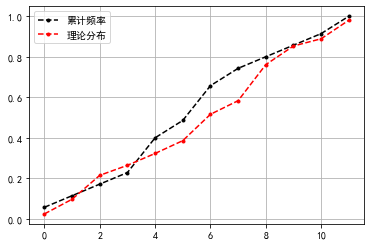

In [14]:
# 密度图表示
df_s['累计频率'].plot(style = '--k.')
df_s['理论分布'].plot(style = '--r.')
plt.legend(loc = 'upper left')
plt.grid()

# 正太分布图
<img src="images/20220517225939.jpg">